In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import anndata as ad
import mygene

from datetime import datetime
import matplotlib.pyplot as plt

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [ ]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")
checkpoint(f"Loaded: {adata.n_obs:,} cells, {adata.n_vars:,} genes")

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUTPUT_H5AD = f"{BASE}/data/01_extGBmap/GBM_downsampled.h5ad"

In [3]:
checkpoint(print(adata))

AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference

### Downsample GBM Dataset to max 5000 per celltype

In [ ]:
checkpoint("Starting downsampling pipeline")
def downsample_adata(adata, celltype_col="decoupler_level1_celltype", 
                     max_downsample=5000):

    
    # Downsampling per celltype
    checkpoint(f"Downsampling per {celltype_col} (keep all ≤{max_downsample}, downsample >{max_downsample} to {max_downsample})...")
    cells_to_keep = []
    
    for celltype in sorted(adata.obs[celltype_col].unique()):
        mask_ct = adata.obs[celltype_col] == celltype
        n_cells = mask_ct.sum()
        
        if n_cells <= max_downsample:
            # Keep all
            cells_to_keep.extend(adata.obs_names[mask_ct])
            checkpoint(f"  {celltype}: {n_cells:,} (keep all)")
        else:
            # Downsample
            sampled_idx = np.random.choice(
                adata.obs_names[mask_ct], 
                size=max_downsample, 
                replace=False
            )
            cells_to_keep.extend(sampled_idx)
            checkpoint(f"  {celltype}: {n_cells:,} -> {max_downsample:,} (downsampled)")
    
    adata_downsampled = adata[cells_to_keep].copy()
    checkpoint(f"Final: {adata_downsampled.n_obs:,} cells (reduced from {adata.n_obs:,})")
    
    return adata_downsampled


# Downsample
adata_downsampled = downsample_adata(adata)

# Save
checkpoint(f"Saving downsampled AnnData to {OUTPUT_H5AD}...")
import anndata as ad
ad.settings.allow_write_nullable_strings = True
adata_downsampled.write(OUTPUT_H5AD)
checkpoint(f"Saved: {OUTPUT_H5AD}")

checkpoint("Done!")

## concatenate downsampled GBMap + HIHAtlas objects (no batch correction yet)

In [4]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"

GBM_PATH = f"{BASE}/data/01_extGBmap/GBM_downsampled.h5ad"
HIHA_PATH = f"{BASE}/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin2.h5ad"

OUT_H5AD = f"{BASE}/data/10_integration_GBM_HIHA"
os.makedirs(OUT_H5AD, exist_ok=True)
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
# ---- 1. load ----
gbm  = sc.read_h5ad(GBM_PATH)
hiha = sc.read_h5ad(HIHA_PATH)
 
print("GBMap:", gbm.shape, " HIHAtlas:", hiha.shape)
 
# ---- 2. check normalization state before touching anything ----
for name, a in [("GBMap", gbm), ("HIHAtlas", hiha)]:
    print(f"{name}: X.max()={a.X.max():.3f}  log1p in uns={a.uns.get('log1p')}")

GBMap: (79510, 25987)  HIHAtlas: (129435, 32338)
GBMap: X.max()=8.180  log1p in uns=None
HIHAtlas: X.max()=106.464  log1p in uns=None


#### rebuild Log-normalization for both

In [6]:
for name, a in [("GBMap", gbm), ("HIHAtlas", hiha)]:
    if a.raw is None:
        raise ValueError(f"{name}: no .raw found - check a.layers for a "
                          "'counts' layer instead and adapt the rebuild below")
 
def rebuild_lognorm(a, name):
    raw_adata = a.raw.to_adata()
    raw_adata.var_names_make_unique()
    raw_adata.obs = a.obs.copy()
    for key in a.obsm:
        raw_adata.obsm[key] = a.obsm[key]
    sc.pp.normalize_total(raw_adata, target_sum=1e4)
    sc.pp.log1p(raw_adata)
    print(f"{name} rebuilt: X.max()={raw_adata.X.max():.3f}, "
          f"log1p flag={raw_adata.uns.get('log1p')}, shape={raw_adata.shape}")
    return raw_adata
 
gbm  = rebuild_lognorm(gbm, "GBMap")
hiha = rebuild_lognorm(hiha, "HIHAtlas")

GBMap rebuilt: X.max()=8.959, log1p flag={'base': None}, shape=(79510, 25987)
HIHAtlas rebuilt: X.max()=9.039, log1p flag={'base': None}, shape=(129435, 32357)


In [7]:
# 3. gene ID mismatch

print("GBMap var_names sample:", gbm.var_names[:5].tolist())
print("HIHAtlas var_names sample:", hiha.var_names[:5].tolist())
print("HIHAtlas var columns:", hiha.var.columns.tolist())

GBMap var_names sample: ['ENSG00000269696', 'ENSG00000230393', 'ENSG00000165244', 'ENSG00000173597', 'ENSG00000158022']
HIHAtlas var_names sample: ['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092', 'ENSG00000239945', 'ENSG00000239906']
HIHAtlas var columns: ['mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


In [8]:
if "feature_name" in gbm.var.columns:
    gbm.var_names = gbm.var["feature_name"].astype(str).values
    gbm.var_names_make_unique()
else:
    print("WARNING: no 'feature_name' column found on gbm.var - ")


if "feature_name" in hiha.var.columns:
    hiha.var_names = hiha.var["feature_name"].astype(str).values
    hiha.var_names_make_unique()
else:
    print("WARNING: no 'feature_name' column found on hiha.var - ")

          

In [9]:
print("GBMap var_names sample:", gbm.var_names[:5].tolist())
print("HIHAtlas var_names sample:", hiha.var_names[:5].tolist())

GBMap var_names sample: ['ZNF470-DT', 'ENSG00000230393', 'ZNF367', 'SULT1B1', 'TRIM63']
HIHAtlas var_names sample: ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'ENSG00000239945', 'ENSG00000239906']


In [10]:
common_genes = gbm.var_names.intersection(hiha.var_names)
print(f"Common genes: {len(common_genes)} "
      f"(GBMap has {gbm.shape[1]}, HIHAtlas has {hiha.shape[1]})")

gbm  = gbm[:, common_genes].copy()
hiha = hiha[:, common_genes].copy()

Common genes: 22586 (GBMap has 25987, HIHAtlas has 32357)


In [11]:
# 4. label datasets before concat
gbm.obs["dataset"]  = "GBMap"
hiha.obs["dataset"] = "HIHAtlas"


#### concatenate

In [15]:
# 5. concatenate 
adata = ad.concat(
    [gbm, hiha],
    join="inner",
    label="dataset_batch",
    keys=["GBMap", "HIHAtlas"],
    index_unique="-",   # avoids silent barcode collisions across datasets
)
adata.obs["dataset"] = pd.Categorical(adata.obs["dataset"])
checkpoint(print("Concatenated:", adata.shape))
checkpoint(print(adata.obs["dataset"].value_counts()))

Concatenated: (208945, 22586)
[2026-09-15 13:36:59] None
dataset
HIHAtlas    129435
GBMap        79510
Name: count, dtype: int64
[2026-09-15 13:36:59] None


In [16]:
# 6. naive preprocessing, NO batch correction
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="dataset")
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
 
sc.pp.scale(adata_hvg, max_value=10)
sc.pp.pca(adata_hvg, n_comps=50, random_state=42)

/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:

sc.pp.neighbors(adata_hvg, random_state=42)
sc.tl.umap(adata_hvg, random_state=42)
 
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
adata.obsm["X_pca"]  = adata_hvg.obsm["X_pca"]

#### pre-integration UMAP

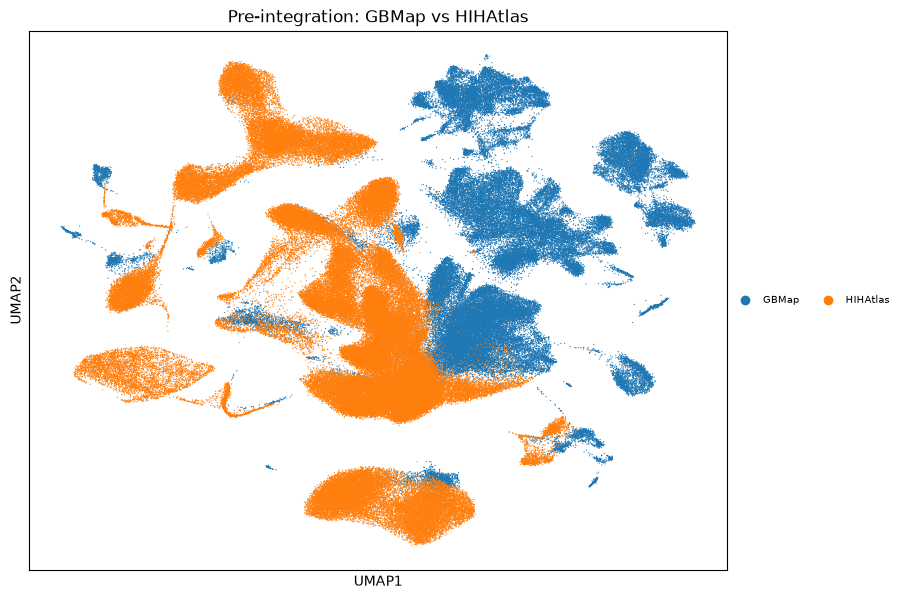

[2026-09-15 13:44:40] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_01_umap_preintegration_dataset.pdf


In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["dataset"], title="Pre-integration: GBMap vs HIHAtlas", ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_01_umap_preintegration_dataset.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [19]:
adata.obsm["X_umap_preharmony"] = adata.obsm["X_umap"].copy()


#### Harmony integration

In [21]:
import scanpy, harmonypy
print(scanpy.__version__, harmonypy.__version__)

1.11.5 2.0.0


/tmp/ipykernel_2404510/3728094523.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(scanpy.__version__, harmonypy.__version__)


In [22]:
import harmonypy as hm
 
ho = hm.run_harmony(
    adata_hvg.obsm["X_pca"],
    adata_hvg.obs,
    ["dataset"],
    random_state=42,
)
 
Z_raw = np.asarray(ho.Z_corr)
n_obs = adata_hvg.n_obs
n_pcs = adata_hvg.obsm["X_pca"].shape[1]
 
if Z_raw.shape == (n_obs, n_pcs):
    Z_harmony = Z_raw
elif Z_raw.shape == (n_pcs, n_obs):
    Z_harmony = Z_raw.T
else:
    raise ValueError(
        f"Unexpected Harmony output shape {Z_raw.shape}; expected "
        f"({n_obs}, {n_pcs}) or ({n_pcs}, {n_obs}). Inspect ho.Z_corr "
        f"directly - harmonypy API may have changed again."
    )
 
print("Harmony output shape resolved to:", Z_harmony.shape)
adata_hvg.obsm["X_pca_harmony"] = Z_harmony
 
sc.pp.neighbors(adata_hvg, use_rep="X_pca_harmony", random_state=42)
sc.tl.umap(adata_hvg, random_state=42)
 
adata.obsm["X_pca_harmony"] = adata_hvg.obsm["X_pca_harmony"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]   # now the harmony-corrected embedding

2026-09-15 14:13:50,045 - harmonypy - INFO - Running Harmony
2026-09-15 14:13:50,046 - harmonypy - INFO -   Parameters:
2026-09-15 14:13:50,047 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-15 14:13:50,047 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-15 14:13:50,047 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-15 14:13:50,048 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-15 14:13:50,048 - harmonypy - INFO -     nclust: 100
2026-09-15 14:13:50,048 - harmonypy - INFO -     block_size: 0.05
2026-09-15 14:13:50,049 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)


2026-09-15 14:13:50,050 - harmonypy - INFO -     theta: [2. 2.]
2026-09-15 14:13:50,050 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-15 14:13:50,050 - harmonypy - INFO -     verbose: True
2026-09-15 14:13:50,051 - harmonypy - INFO -     random_state: 42
2026-09-15 14:13:50,051 - harmonypy - INFO -   Data: 50 PCs × 208945 cells
2026-09-15 14:13:50,052 - harmonypy - INFO -   Batch variables: ['dataset']
2026-09-15 14:13:50,265 - harmonypy - INFO - Computing initial centroids...
2026-09-15 14:13:55,251 - harmonypy - INFO - Initialization complete.
2026-09-15 14:13:55,252 - harmonypy - INFO - Iteration 1 of 10
2026-09-15 14:13:59,332 - harmonypy - INFO - Iteration 2 of 10
2026-09-15 14:14:03,665 - harmonypy - INFO - Iteration 3 of 10
2026-09-15 14:14:08,031 - harmonypy - INFO - Iteration 4 of 10
2026-09-15 14:14:12,406 - harmonypy - INFO - Iteration 5 of 10
2026-09-15 14:14:16,773 - harmonypy - INFO - Iteration 6 of 10
2026-09-15 14:14:21,142 - harmonypy - INFO - Iterat

Harmony output shape resolved to: (208945, 50)


#### Plot: post-integration

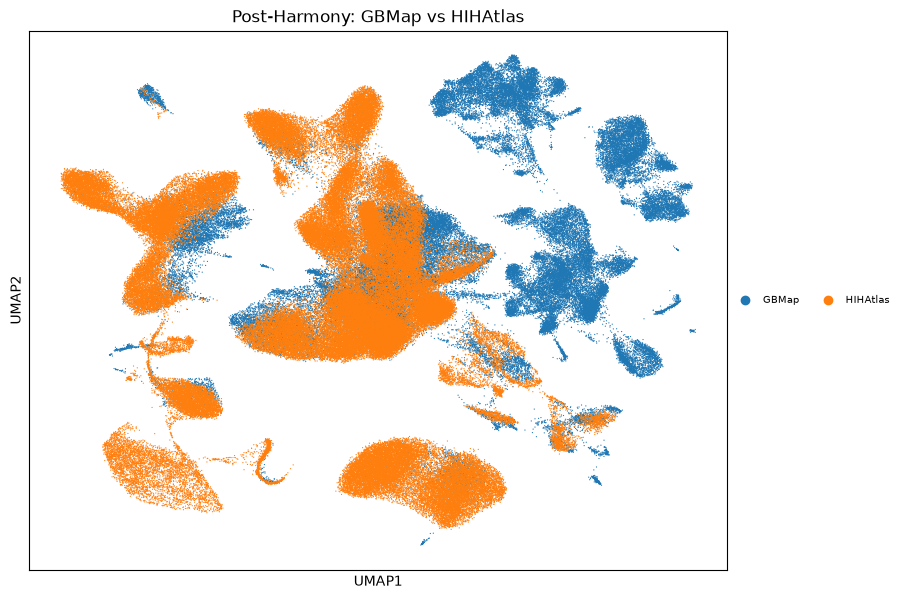

[2026-09-15 14:16:29] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_01_umap_post_harmony_dataset.pdf


In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["dataset"], title="Post-Harmony: GBMap vs HIHAtlas", ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_01_umap_post_harmony_dataset.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [24]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

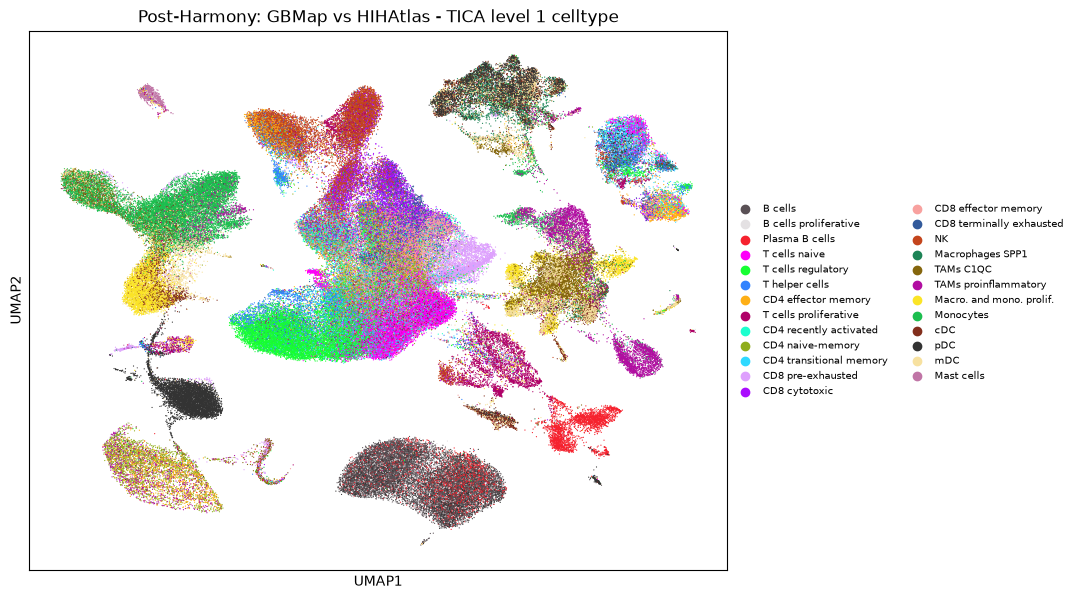

[2026-09-15 14:27:41] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_01_postharmony_umap_celltype.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["decoupler_level1_celltype"], title="Post-Harmony: GBMap vs HIHAtlas - TICA level 1 celltype", palette=celltype_palette, ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_01_postharmony_umap_celltype.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

#### save new H5AD file

In [30]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True

adata.write(os.path.join(OUT_H5AD, "gbmap_hiha_concat_harmony.h5ad"))


## celltype grid

In [3]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad")
checkpoint(f"Loaded: {adata.n_obs:,} cells, {adata.n_vars:,} genes")

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT = f"{BASE}/results/10_integration_GBM_HIHA"

[2026-09-16 10:34:50] Loaded: 208,945 cells, 22,586 genes


In [7]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

In [10]:
cats = list(adata.obs["decoupler_level1_celltype"].cat.categories)

# Sanity-Check: sind alle Kategorien in celltype_palette abgedeckt?
missing = set(cats) - set(celltype_palette.keys())
assert not missing, f"Fehlende Farben für: {missing}"

# Vollständige, korrekt geordnete Farbliste in .uns setzen
adata.uns["decoupler_level1_celltype_colors"] = [celltype_palette[c] for c in cats]

In [26]:
celltype_key = "decoupler_level1_celltype"

label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
adata.obs["condition"] = adata.obs["dataset"].map(label_map)
condition_key = "condition"

count_df = (
    adata.obs
    .groupby([celltype_key, condition_key], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["GBM", "Healthy"], fill_value=0)
)

count_df


condition_order = ["Healthy", "GBM"]
condition_palette = {"Healthy": "#69DD82", "GBM": "#CA425F"}

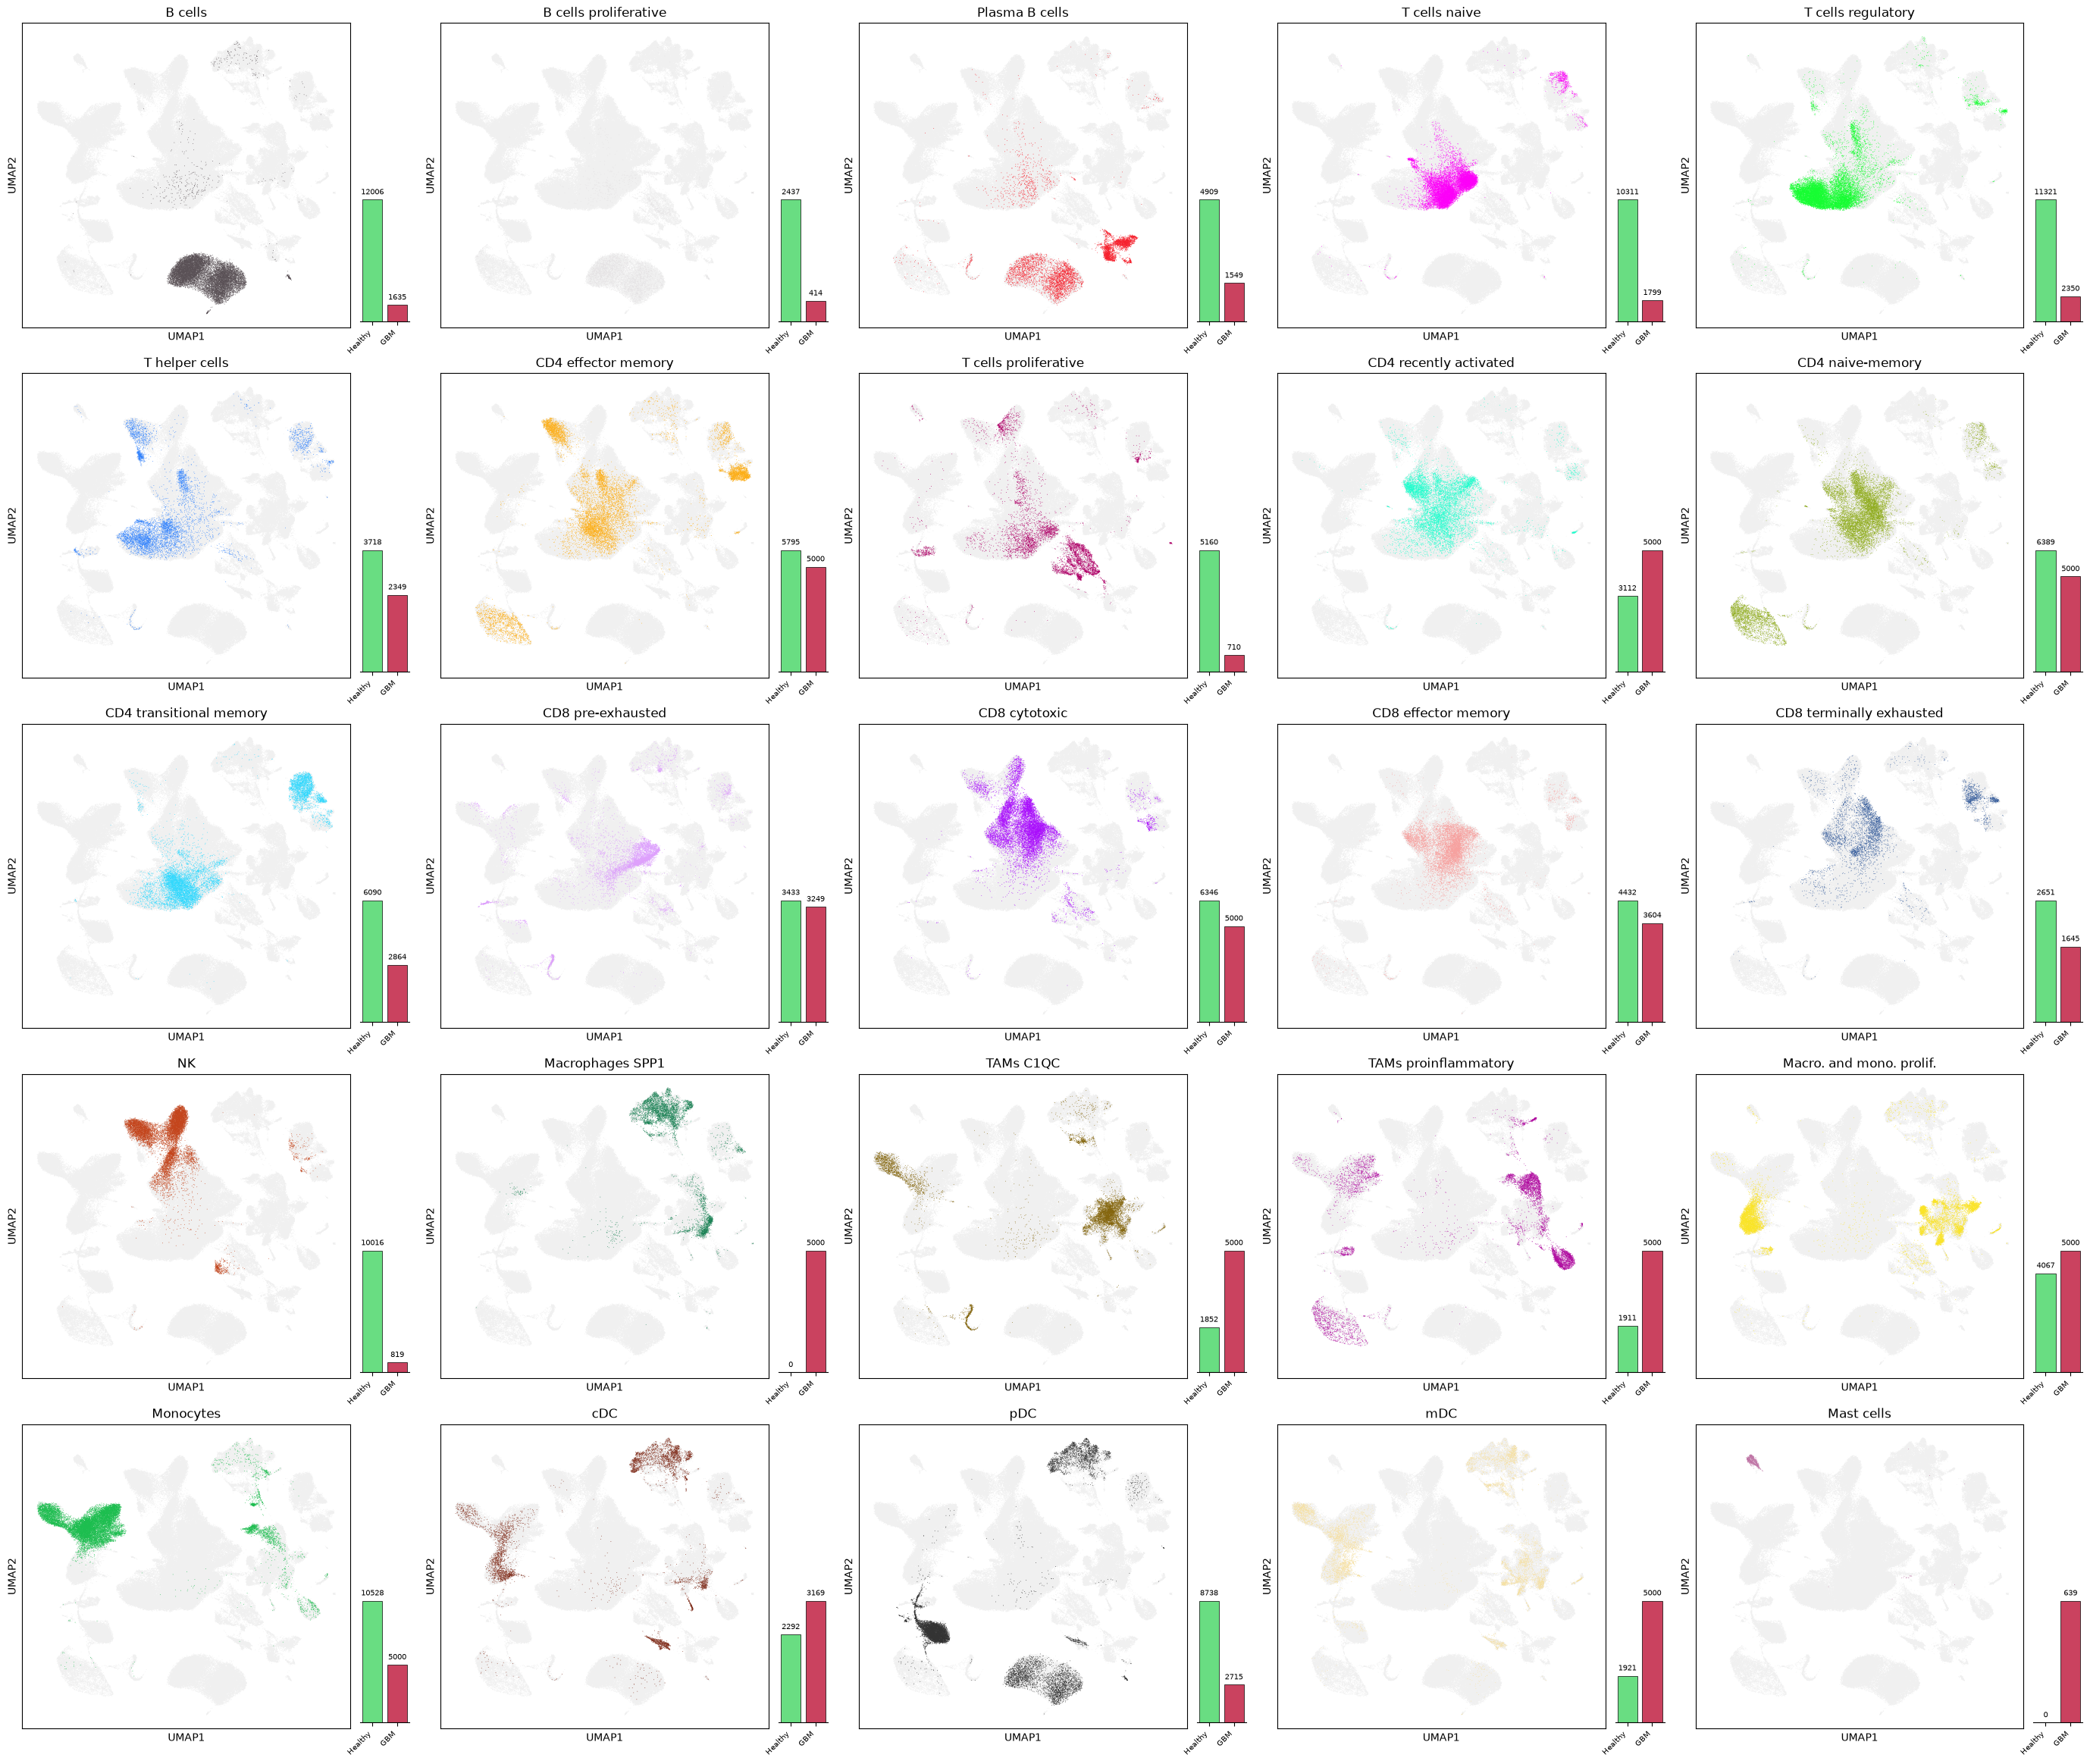

In [35]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

n_cols = 5
n_rows = -(-len(cats) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = np.asarray(axes).flatten()

for i, ct in enumerate(cats):
    ax = axes[i]
    sc.pl.umap(
        adata,
        color="decoupler_level1_celltype",
        groups=[ct],           # nur diesen Zelltyp farbig hervorheben
        na_color="#f0f0f0",    # sehr helles Grau für alle anderen Zellen
        ax=axes[i],
        show=False,
        title=ct,
        size=1.5,
        frameon=True,
        legend_loc=None,       # Legende weglassen, sonst pro Panel überladen
    )
    axes[i].set_rasterized(True)

    ct_mask = (adata.obs[celltype_key].astype(str).eq(str(ct))) # select cells of each celltype

    counts = (adata.obs.loc[ct_mask, condition_key].value_counts().reindex(condition_order, fill_value=0))
    bar_colors = [condition_palette[label] for label in condition_order]

    x = np.arange(len(condition_order))

    ax_bar = inset_axes(
        ax,
        width="15%",          # narrower
        height="50%",         # shorter
        loc="lower left",
        bbox_to_anchor=(1.03, 0.02, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )
    ax_bar.bar(x, counts.to_numpy(), color=bar_colors, edgecolor="black", linewidth=0.5)

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(condition_order, rotation=45, ha="right", fontsize=7)
    ax_bar.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax_bar.yaxis.set_visible(False)

    ax_bar.spines["left"].set_visible(False)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)

    max_count = max(counts.max(), 1)

    for x, value in enumerate(counts.values):
        ax_bar.text(x, value + 0.03 * max_count,
            str(value),
            ha="center",
            va="bottom",
            fontsize=7)
        
    ax_bar.set_ylim(0, max_count * 1.25)

    ax_bar.set_facecolor("white")
    ax_bar.patch.set_alpha(0.9)

for j in range(len(cats), len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(
    left=0.05,
    right=0.93,
    bottom=0.05,
    top=0.95,
    wspace=0.275,
    hspace=0.15
)
plt.savefig(os.path.join(OUT, "10_01_umap_grid_ct_lvl1_n.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()